<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_07_3_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 7: PyTorch Building Blocks**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 7 Material


* Part 7.1: Model Structure [[Video]]() [[Notebook]](t81_558_class_07_1_model_structure.ipynb)
* Part 7.2: Learnable Layers [[Video]]() [[Notebook]](t81_558_class_07_2_learnable_layers.ipynb)
* **Part 7.3: Nonlinearities (Activations)** [[Video]]() [[Notebook]](t81_558_class_07_3_transfer.ipynb)
* Part 7.4: Normalization & Regularization [[Video]]() [[Notebook]](t81_558_class_07_4_normalization.ipynb)
* Part 7.5: Shape [[Video]]() [[Notebook]](t81_558_class_07_5_shapes.ipynb)



# Google CoLab Instructions

The following code checks that Google CoLab is and sets up the correct hardware settings for PyTorch.


In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
Using device: cpu


# Part 7.3: Nonlinearities (Activations)

Activation functions are the source of expressive power in a neural network. The learnable layers introduced earlier in this module, such as `nn.Linear` and `nn.Conv2d`, are linear operations. If we stacked these layers without anything between them, the entire network would collapse mathematically into a single linear transformation, regardless of its depth. A network with one hundred linear layers and no activations would have the same representational capacity as a network with one linear layer. Activation functions break this collapse by inserting a nonlinear step between layers, which allows the composition of layers to approximate complex, curved decision boundaries and arbitrary continuous functions.

In PyTorch, an activation function is just another module or functional call placed between learnable layers. Each activation transforms its input element by element and produces an output of the same shape. Although dozens of activation functions have been proposed over the decades, modern practice in 2026 has converged on a relatively small set of choices. The discussion below focuses on the activations you are most likely to encounter and use in current architectures.

## Why Nonlinearity Matters

Consider two stacked linear layers without an activation between them. The first layer computes $y_1 = W_1 x + b_1$, and the second computes $y_2 = W_2 y_1 + b_2$. Substituting gives $y_2 = W_2 W_1 x + W_2 b_1 + b_2$, which simplifies to $y_2 = W' x + b'$ where $W' = W_2 W_1$ and $b' = W_2 b_1 + b_2$. The composition is itself a linear function. No matter how many layers we stack, the result is equivalent to a single linear layer.

Inserting a nonlinear function between the two layers breaks this equivalence. The composition $y_2 = W_2 \sigma(W_1 x + b_1) + b_2$ cannot be reduced to a single linear transformation. With enough such compositions, neural networks become universal function approximators, capable of representing any continuous function to arbitrary precision given sufficient width or depth.

## ReLU and Its Modern Variants

The Rectified Linear Unit, or ReLU, defined as $\text{ReLU}(x) = \max(0, x)$, became the default activation for hidden layers in deep networks during the 2010s and remains widely used today. It is computationally cheap, easy to differentiate, and avoids the vanishing gradient problem that plagued earlier activations such as sigmoid and tanh in deep networks. Its gradient is exactly one for positive inputs and exactly zero for negative inputs, which keeps signal flowing through deep stacks during backpropagation.

ReLU does have a known weakness called the dying ReLU problem. When a neuron's input is consistently negative, its gradient is zero and the neuron stops updating. Several variants address this issue. Leaky ReLU replaces the flat zero region with a small negative slope, typically 0.01, so that gradients can still flow when the input is negative. Parametric ReLU treats this slope as a learnable parameter rather than a fixed constant.

In PyTorch these are available as `nn.ReLU`, `nn.LeakyReLU`, and `nn.PReLU`, or as functional calls under `torch.nn.functional`. ReLU remains a strong default choice for convolutional networks and many feed-forward architectures.

## GELU: The Transformer Standard

The Gaussian Error Linear Unit, or GELU, has become the standard activation in transformer architectures. Defined as $\text{GELU}(x) = x \cdot \Phi(x)$, where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution, GELU can be interpreted as weighting each input by the probability that a Gaussian random variable would fall below it. The result is a smooth, non-monotonic function that closely resembles ReLU for large positive and large negative inputs but transitions smoothly through zero rather than producing a hard corner.

GELU appears in the original BERT paper, in the GPT family, in Vision Transformers, and in most large language model architectures released since 2018. The smoothness of GELU produces gradients that are nonzero everywhere, which avoids the dying neuron problem entirely, and empirically GELU has been shown to outperform ReLU on transformer-style workloads. PyTorch provides this activation as `nn.GELU`.

## SiLU and Swish

The Sigmoid Linear Unit, or SiLU, is defined as $\text{SiLU}(x) = x \cdot \sigma(x)$, where $\sigma$ is the standard sigmoid function. This activation is also known as Swish, the name given to it by Google researchers who discovered it through automated search over candidate activation functions. SiLU shares the smooth, non-monotonic shape of GELU and the two functions behave very similarly in practice.

SiLU has become the activation of choice in several important architecture families. It is used in EfficientNet for image classification, in the YOLO family for object detection, and inside the gated feed-forward blocks of LLaMA and other recent large language models, where it appears as part of the SwiGLU gating mechanism. PyTorch exposes this activation as `nn.SiLU`.

## Output Layer Activations

Activations on the final layer of a network play a different role than activations in hidden layers. Their job is to shape the output to match the expected form of the target. For binary classification, the sigmoid function squashes a single logit into the range $(0, 1)$ so that it can be interpreted as a probability. For multi-class classification, the softmax function converts a vector of logits into a probability distribution that sums to one. For regression problems, the output layer typically uses no activation at all, allowing the network to produce values across the full real line.

A practical note: in PyTorch, the loss functions `nn.BCEWithLogitsLoss` and `nn.CrossEntropyLoss` apply sigmoid and softmax internally for numerical stability. When using these losses, you should output raw logits from your network rather than applying the activation yourself.

## Choosing an Activation in 2026

The choice of activation function has narrowed considerably in modern practice. For convolutional networks, ReLU remains a perfectly reasonable default, although SiLU is increasingly common in newer architectures. For transformer-based models, GELU is the near-universal choice for the feed-forward sublayers, with SiLU appearing in gated variants such as SwiGLU. For most other architectures, GELU and SiLU are interchangeable and either is a strong starting point.

The older sigmoid and tanh activations are now restricted to specific roles such as gating mechanisms inside recurrent cells or producing bounded outputs. They are rarely used as hidden-layer activations in deep networks because their gradients saturate at the extremes, which slows or stops learning.

## Python Example: Comparing Activation Functions

The following example evaluates several common activation functions across a range of input values and visualizes their behavior. This is a good way to build intuition for the shapes of these functions and how they differ from one another.

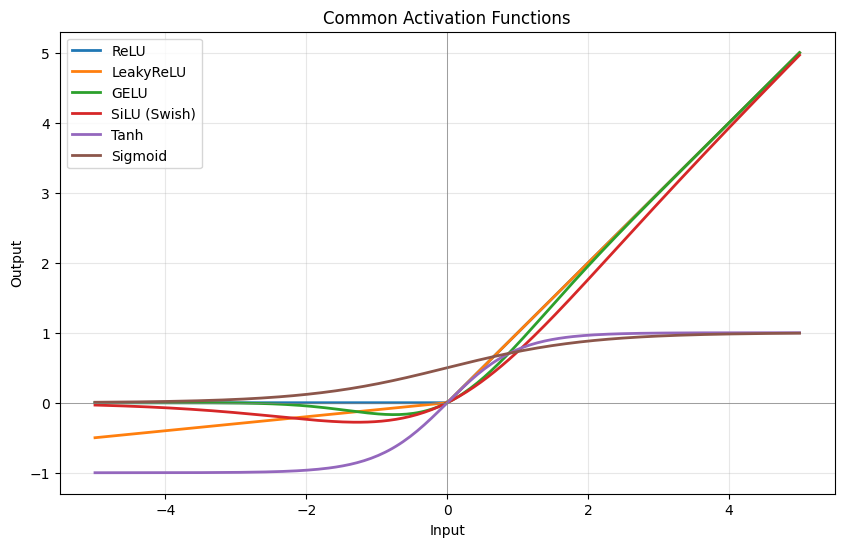

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Generate input values across a useful range
x = torch.linspace(-5, 5, 200)

# Define the activations we want to compare
activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(negative_slope=0.1),
    "GELU": nn.GELU(),
    "SiLU (Swish)": nn.SiLU(),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
}

# Plot each activation
plt.figure(figsize=(10, 6))
for name, fn in activations.items():
    y = fn(x)
    plt.plot(x.numpy(), y.numpy(), label=name, linewidth=2)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Beyond visualizing the activations themselves, it is useful to see how they integrate into a real network. The following example builds a small feed-forward block that uses GELU activations between its linear layers, which is the pattern you will see in most modern transformer feed-forward sublayers.

In [3]:
import torch
import torch.nn as nn

class FeedForwardBlock(nn.Module):
    """A simple feed-forward block using GELU, similar to a transformer FFN."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

# Instantiate the block and run a sample tensor through it
model = FeedForwardBlock(input_dim=128, hidden_dim=512, output_dim=10)
sample_input = torch.randn(4, 128)  # batch of 4, feature dim 128
output = model(sample_input)

print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {output.shape}")
print(model)

Input shape:  torch.Size([4, 128])
Output shape: torch.Size([4, 10])
FeedForwardBlock(
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (act): GELU(approximate='none')
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


This pattern of linear, activation, linear is the basic building block of the feed-forward sublayer in every transformer model. Swapping `nn.GELU()` for `nn.ReLU()` or `nn.SiLU()` is often a one-line change, and it is worth experimenting with these alternatives when developing your own architectures.